<a href="https://colab.research.google.com/github/OscarBF99/P-cticas-profesionales/blob/main/Dimuon_SingleMu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import math
from math import factorial
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv(r"Dimuon_SingleMu.csv", delimiter=',', header=0)

In [3]:
# Valores únicos de las cargas

print("Valores únicos en Q1")
print(df['Q1'].unique())

print("Valores únicos en Q2")
print(df['Q2'].unique())

Valores únicos en Q1
[ 1 -1]
Valores únicos en Q2
[-1  1]


In [4]:
# Filtrar de forma que solo se tengan eventos con corte pt>20 GeV

mask_pt = (df["pt1"] > 20) & (df["pt2"] > 20)
print("Eventos totales:", len(df))
print("Eventos filtrados > 20 :", mask_pt.sum())

print(df[["pt1","pt2"]].dtypes)
print(df[["pt1","pt2"]].head())

Eventos totales: 83761
Eventos filtrados > 20 : 12740
pt1    float64
pt2    float64
dtype: object
       pt1      pt2
0   4.2116   1.2556
1   2.1479  19.5453
2  21.0732   2.3864
3  18.5889   1.8721
4  11.8194   0.9408


In [5]:
# Filtrar para obtener eventos con |eta|<2.1 (para ambos, eta1 y eta2)

mask_eta = (df["eta1"].abs() < 2.1) & (df["eta2"].abs() < 2.1)

print("Eventos totales:", len(df))
print("Eventos filtrados < 2.1 :", mask_eta.sum())

print(df[["eta1","eta2"]].dtypes)
print(df[["eta1","eta2"]].head())

df_filtrado = df[mask_pt & mask_eta].copy()

print(mask_pt.head())

Eventos totales: 83761
Eventos filtrados < 2.1 : 54365
eta1    float64
eta2    float64
dtype: object
     eta1    eta2
0  2.2366  2.2683
1 -2.0159 -1.0826
2  1.5948  1.5352
3  1.6422  1.9704
4  0.8711  2.0107
0    False
1    False
2    False
3    False
4    False
dtype: bool


In [6]:
# Filtro de eventos de muones con cargas opuestas (Q1*Q2 = -1)

mask_carga = (df_filtrado["Q1"] * df_filtrado["Q2"] == -1)

# Aplica el filtro al dataframe

df_filtrado = df_filtrado[mask_carga].copy()

print("Eventos totales despues del filtro:", len(df_filtrado))

# jjjjj

Eventos totales despues del filtro: 11375


In [7]:
# 1. Eventos totales

n_total = len(df)

# 2. Corte en pt

mask_pt = (df["pt1"] > 20) & (df["pt2"] > 20)
df_pt = df[mask_pt]
n_pt = len(df_pt)

# 3. Corte en eta

mask_eta = (abs(df_pt["eta1"]) < 2.1) & (abs(df_pt["eta2"]) < 2.1)
df_eta = df_pt[mask_eta]
n_eta = len(df_eta)

# 4. Corte de cargas opuestas

mask_carga = (df_eta["Q1"] * df_eta["Q2"] == -1)
df_carga = df_eta[mask_carga]
n_carga = len(df_carga)

# 5. Corte de tipo Global

mask_type = (df_carga["type1"] == "G") & (df_carga["type2"] == "G")
df_final = df_carga[mask_type].copy()
n_type = len(df_final)

In [8]:
# Construir tabla de flujo de cortes

cut_flow = pd.DataFrame({

    "Corte": [

        "Eventos totales",
        "pt > 20 GeV",

        "|eta| < 2.1",
        "Cargas opuestas",

        "Ambos Global"

    ],

    "Eventos restantes": [

        n_total,
        n_pt,
        n_eta,
        n_carga,
        n_type

    ]

})



print(cut_flow)

             Corte  Eventos restantes
0  Eventos totales              83761
1      pt > 20 GeV              12740
2      |eta| < 2.1              11375
3  Cargas opuestas              11375
4     Ambos Global              10780


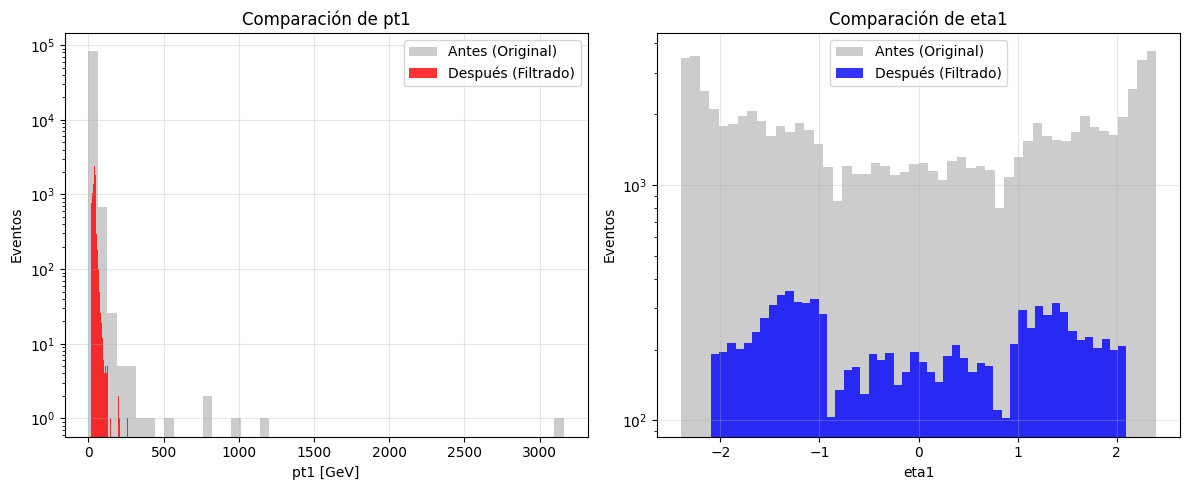

In [9]:
# Comparación pt1 y eta1 en subplots

variables = ['pt1', 'eta1']
colores = ['red', 'blue']

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    axs[i].hist(df[var], bins=50, alpha=0.4, label='Antes (Original)', color='gray')
    axs[i].hist(df_final[var], bins=50, alpha=0.8, label='Después (Filtrado)', color=colores[i])
    axs[i].set_title(f'Comparación de {var}')
    if var == 'pt1':
        axs[i].set_xlabel(f'{var} [GeV]')
    else:
        axs[i].set_xlabel(var)
    axs[i].set_ylabel('Eventos')
    axs[i].legend()
    axs[i].grid(True, alpha=0.3)
    axs[i].set_yscale('log')
plt.tight_layout()
plt.show()


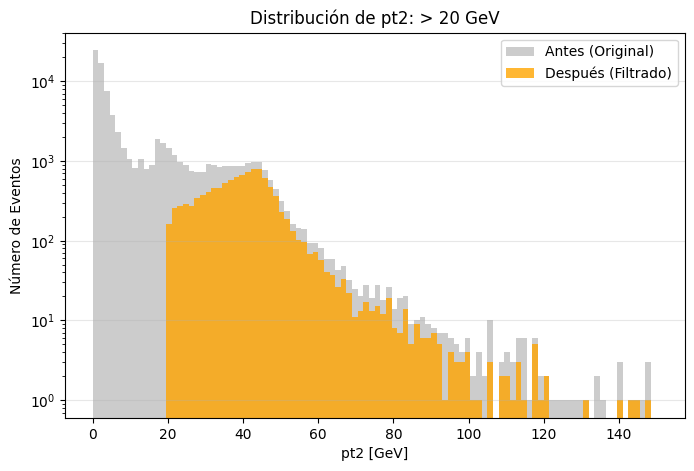

In [10]:
# Momento transverso pt2

plt.figure(figsize=(8, 5))
plt.hist(df['pt2'], bins=100, range=(0, 150), alpha=0.4, label='Antes (Original)', color='gray')
plt.hist(df_final['pt2'], bins=100, range=(0, 150), alpha=0.8, label='Después (Filtrado)', color='orange')
plt.title('Distribución de pt2: > 20 GeV')
plt.xlabel('pt2 [GeV]')
plt.ylabel('Número de Eventos')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

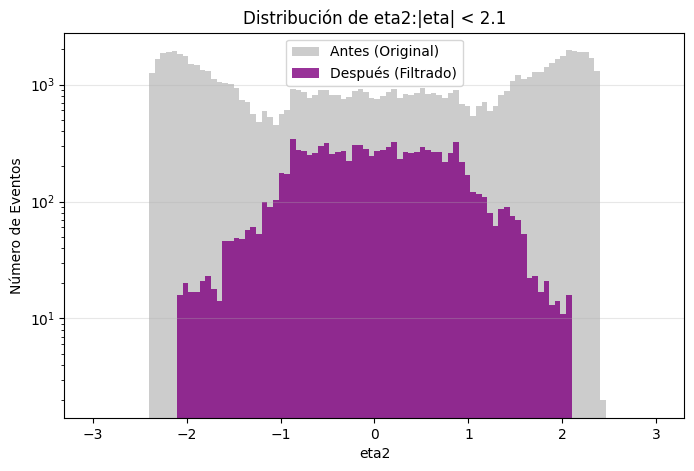

In [11]:
# Pseudorapidez eta2

plt.figure(figsize=(8, 5))
plt.hist(df['eta2'], bins=100, range=(-3, 3), alpha=0.4, label='Antes (Original)', color='gray')
plt.hist(df_final['eta2'], bins=100, range=(-3, 3), alpha=0.8, label='Después (Filtrado)', color='purple')
plt.title('Distribución de eta2:|eta| < 2.1')
plt.xlabel('eta2')
plt.ylabel('Número de Eventos')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

In [12]:
# Cálculo de masa invariante (sin filtros)

df["M"] = np.sqrt(2 * df["pt1"] * df["pt2"] * (np.cosh(df["eta1"] - df["eta2"]) - np.cos(df["phi1"] - df["phi2"])))

# Cálculo de masa invariante (con filtros)

df_final["M"] = np.sqrt(2 * df_final["pt1"] * df_final["pt2"] * (np.cosh(df_final["eta1"] - df_final["eta2"]) - np.cos(df["phi1"] - df_final["phi2"])))

# Verificamos la nueva columna (Masa invariante antes)

print("Masa invariante (Antes) :")
print(df["M"].dtypes)
print(df["M"].head(10))

# Verificamos la nueva columna (Masa invariante después)
print("Masa invariante (Después) :")
print(df_final["M"].dtypes)
print(df_final["M"].head(10))

Masa invariante (Antes) :
float64
0     2.132997
1    13.678308
2     4.381502
3     3.258940
4     4.016878
5    89.685376
6    15.393482
7     4.239407
8    15.279434
9    89.884973
Name: M, dtype: float64
Masa invariante (Después) :
float64
5       89.685376
9       89.884973
14      88.618624
42      92.212436
44      84.410142
46     115.076225
48      96.836431
60      93.369530
100     90.701026
103     93.704491
Name: M, dtype: float64


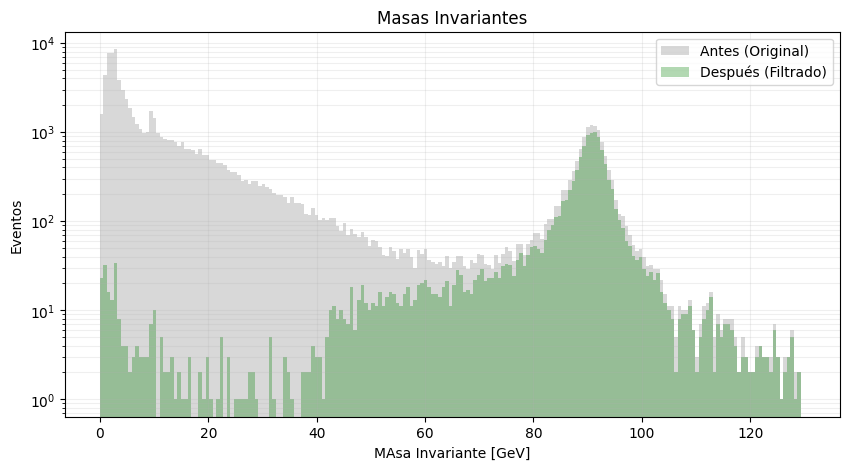

In [13]:
# Graficamos la comparación

plt.figure(figsize=(10,5))
plt.hist(df["M"], bins=200, range=(0, 130), alpha=0.3, color='gray', label='Antes (Original)')
plt.hist(df_final["M"], bins=200, range=(0, 130), alpha=0.3, color='green', label='Después (Filtrado)')

plt.yscale('log')
plt.title('Masas Invariantes')
plt.xlabel('MAsa Invariante [GeV]')
plt.ylabel('Eventos')
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()

In [14]:
# Valores de los picos

promedio_antes = df["M"].mean()
pico_frecuente = df["M"].round(0).mode()[0]

print("Valores del Pico (Bosón Z)")
print(f"Valor del pico (Moda):     {pico_frecuente:.2f} GeV")
print(f"Promedio de la campana:    {promedio_antes:.2f} GeV")
print(f"Desviación estándar:       {df['M'].std():.2f} GeV")


promedio_después = df_final["M"].mean()
pico_frecuente = df_final["M"].round(0).mode()[0]

print("Valores del Pico (Bosón Z)")
print(f"Valor del pico (Moda):     {pico_frecuente:.2f} GeV")
print(f"Promedio de la campana:    {promedio_después:.2f} GeV")
print(f"Desviación estándar:       {df_final['M'].std():.2f} GeV")

Valores del Pico (Bosón Z)
Valor del pico (Moda):     2.00 GeV
Promedio de la campana:    21.86 GeV
Desviación estándar:       31.22 GeV
Valores del Pico (Bosón Z)
Valor del pico (Moda):     91.00 GeV
Promedio de la campana:    87.40 GeV
Desviación estándar:       17.94 GeV
